Customer Spending Dataset Overview

In [50]:
import pandas as pd


In [51]:
data = pd.read_csv("customer_data.csv")


In [52]:
data.head()

,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


In [53]:
data.tail()

,name,age,gender,education,income,country,purchase_frequency,spending
995,Jason Haas,42,Female,PhD,98170,Bosnia and Herzegovina,0.7,17435.95
996,Sharon Valdez,39,Male,High School,59174,Eritrea,0.9,11662.83
997,Andrew Taylor,50,Male,Master,59808,Serbia,0.4,7196.16
998,Jessica Johnson,50,Female,Master,58272,Cyprus,0.7,13939.52
999,Brian Williams,38,Female,Bachelor,32512,Turkey,0.5,8312.80


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   education           1000 non-null   object 
 4   income              1000 non-null   int64  
 5   country             1000 non-null   object 
 6   purchase_frequency  1000 non-null   float64
 7   spending            1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [55]:
data.shape

(1000, 8)

In [ ]:
 data.describe()

,age,income,purchase_frequency,spending
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.754000,59277.852000,0.554600,9613.296835
std,13.778582,23258.377128,0.284675,5484.707210
min,18.000000,20031.000000,0.100000,611.985000
25%,30.000000,38825.500000,0.300000,5020.425000
50%,42.000000,58972.000000,0.600000,9430.395000
75%,54.000000,79114.000000,0.800000,13645.507500
max,65.000000,99780.000000,1.000000,25546.500000


In [57]:
data.columns

Index(['name', 'age', 'gender', 'education', 'income', 'country',
       'purchase_frequency', 'spending'],
      dtype='object')

In [58]:
data.dtypes

name                   object
age                     int64
gender                 object
education              object
income                  int64
country                object
purchase_frequency    float64
spending              float64
dtype: object

In [59]:
missing_values = data.isnull().any(axis=1)
print("Rows with Missing Values:")
print(data[missing_values == True])

Rows with Missing Values:
Empty DataFrame
Columns: [name, age, gender, education, income, country, purchase_frequency, spending]
Index: []


In [60]:
duplicate_rows = data[data.duplicated()]
print("Duplicated Rows:")
print(duplicate_rows)

Duplicated Rows:
Empty DataFrame
Columns: [name, age, gender, education, income, country, purchase_frequency, spending]
Index: []


In [61]:
data.dropna(axis=0, inplace=True)

In [62]:
data.drop_duplicates(inplace=True)

Segmenting Customer by Age & Gender

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

Age Grounp Distribution:
Age Group
18-35    371
36-50    316
51-65    313
65+        0
Name: count, dtype: int64
Gender Distribution
gender
Male      501
Female    499
Name: count, dtype: int64


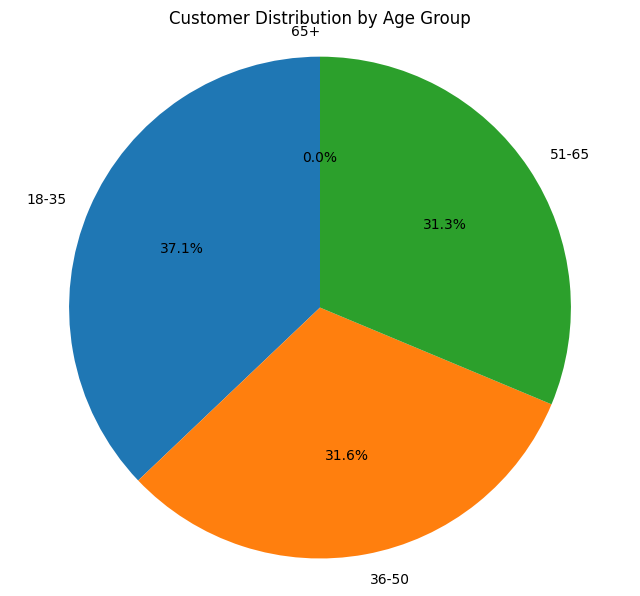

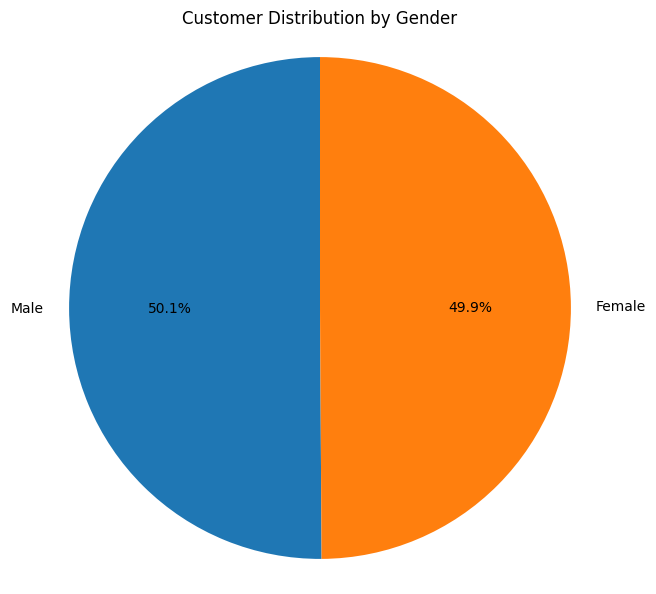

In [64]:
age_bins =[18, 36, 51, 66, 100]
age_labels = ['18-35', '36-50', '51-65', '65+']
data["Age Group"] = pd.cut(data["age"], bins=age_bins, labels=age_labels, right=False)
age_group_counts = data["Age Group"].value_counts()
gender_counts = data["gender"].value_counts()
print("Age Grounp Distribution:")
print(age_group_counts)
print("Gender Distribution")
print(gender_counts)
plt.figure(figsize=(8,8))
plt.pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Distribution by Age Group")
plt.subplots_adjust(top=0.80)
plt.axis('equal')
plt.show()
plt.figure(figsize=(8,8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Distribution by Gender")
plt.subplots_adjust(top=0.80)
plt.axis('equal')
plt.show()

Segementing Customer by Education Level

Percentage share of spending by education level:
     education  percentage
3          PhD   29.026812
0     Bachelor   26.843618
2       Master   24.960478
1  High School   19.169092


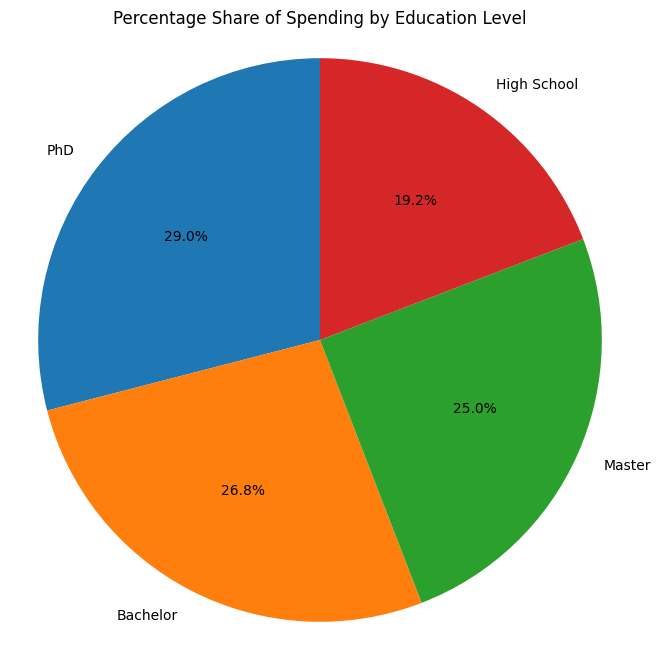

In [65]:
education_spending = data.groupby('education')['spending'].sum().reset_index()
total_spending = education_spending['spending'].sum()
education_spending["percentage"] = education_spending['spending']/total_spending *100
education_spending = education_spending.sort_values(by='percentage', ascending=False)
print("Percentage share of spending by education level:")
print(education_spending[['education','percentage']])
plt.figure(figsize=(8,8))
plt.pie(education_spending['percentage'], labels=education_spending['education'], autopct='%1.1f%%', startangle=90)
plt.title("Percentage Share of Spending by Education Level")
plt.axis('equal')
plt.show()

Calculating Average Customer Spending by Country

Top 5 Countries by Average Customer Spending:
                         country    spending
180                 Saint Helena  24055.7850
97                       Hungary  19438.7925
182                  Saint Lucia  19405.7150
68   Falkland Islands (Malvinas)  18617.1200
212                     Thailand  17015.4125


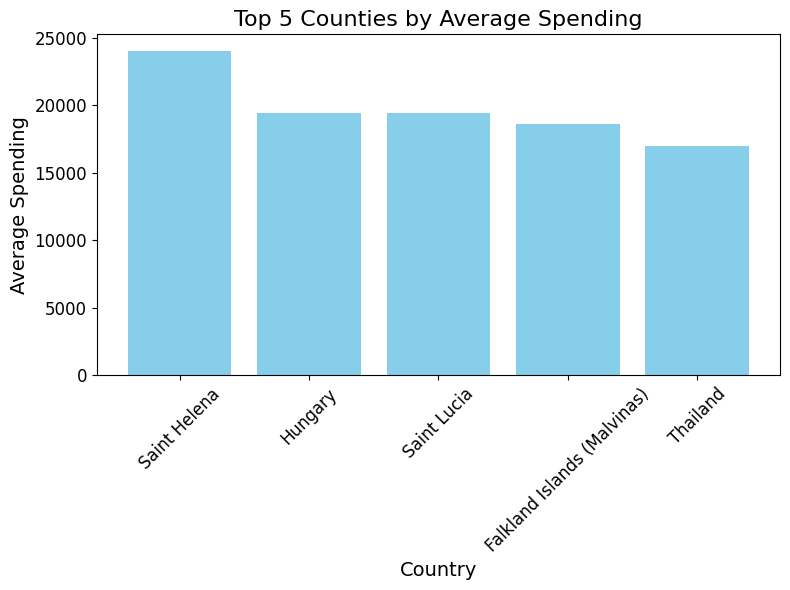

In [66]:
average_spending_by_country = data.groupby("country")["spending"].mean().reset_index()
top_5_countries = average_spending_by_country.sort_values(by='spending', ascending=False).head(5)
print("Top 5 Countries by Average Customer Spending:")
print(top_5_countries)
plt.figure(figsize=(8,6))
plt.bar(top_5_countries['country'],top_5_countries['spending'], color='skyblue')
plt.title("Top 5 Counties by Average Spending", fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Average Spending', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Finding Correlation Between Purchase Frequency & Customer Spending

Correlation Coefficient Between Purchase Frequency and Spending: 0.8951607373493099


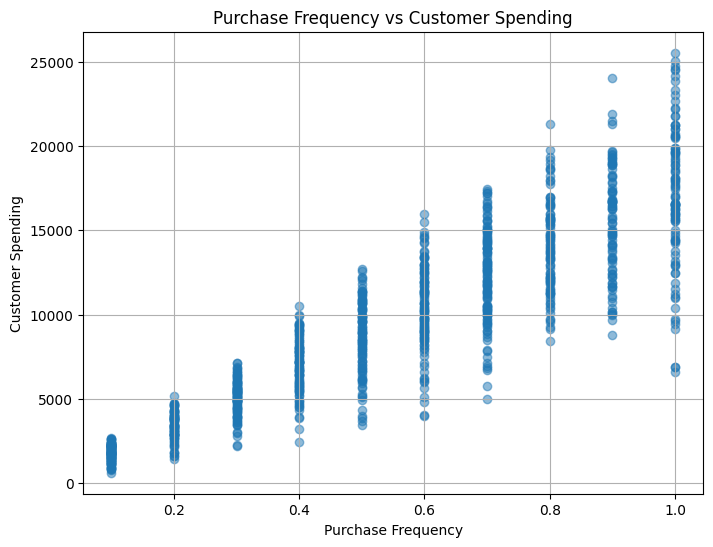

In [67]:
correlation_coefficient = data['purchase_frequency'].corr(data['spending'])
print(f"Correlation Coefficient Between Purchase Frequency and Spending: {correlation_coefficient}")
plt.figure(figsize=(8,6))
plt.scatter(data['purchase_frequency'], data['spending'], alpha=0.5)
plt.title("Purchase Frequency vs Customer Spending")
plt.xlabel('Purchase Frequency')
plt.ylabel('Customer Spending')
plt.grid(True)
plt.show()

Finding Correlation Between Customer Income & Customer Spending


Average Spending by Income Category:
  Income Category      spending
0             Low   8907.921575
1          Medium   9152.301580
2            High  10156.447531

Correlation Coefficient Between Income and Spending: 0.1229


/var/folders/31/dlz_yl292kd0mpd8mj2mpb5r0000gn/T/ipykernel_1167/2239377587.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_spending_by_income = data.groupby('Income Category')['spending'].mean().reset_index()


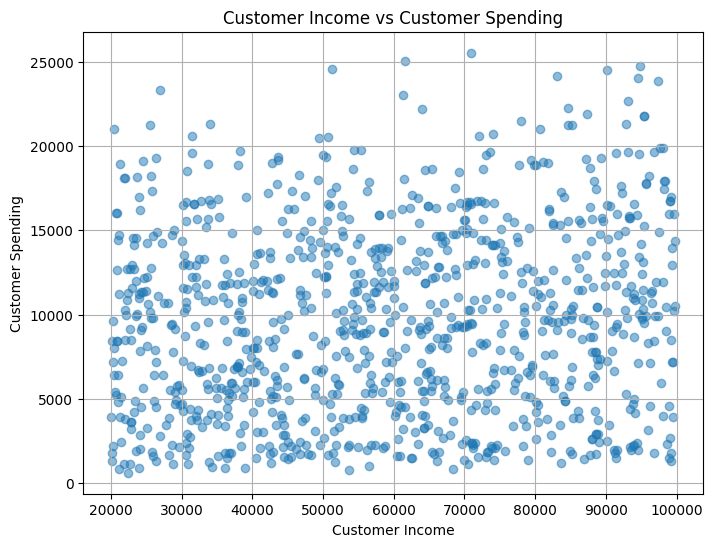

In [68]:
income_bins = [0, 30000, 60000, float('inf')]
income_labels = ['Low', 'Medium', 'High']
data['Income Category'] = pd.cut(data['income'], bins=income_bins, labels=income_labels, right=False)
average_spending_by_income = data.groupby('Income Category')['spending'].mean().reset_index()
print("\nAverage Spending by Income Category:")
print(average_spending_by_income)
correlation_coefficient = data['income'].corr(data['spending'])
print(f"\nCorrelation Coefficient Between Income and Spending: {correlation_coefficient:.4f}")
plt.figure(figsize=(8,6))
plt.scatter(data["income"], data["spending"], alpha=0.5)
plt.title("Customer Income vs Customer Spending")
plt.xlabel('Customer Income')
plt.ylabel('Customer Spending')
plt.grid(True)
plt.show()

Feature Importance Analysis with Random Forest


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder


In [70]:
data = pd.read_csv("customer_data.csv")

Ranked list of features by importances:
              Feature  Importance
5  purchase_frequency    0.802933
2           education    0.087910
0                 age    0.073835
3              income    0.022408
4             country    0.007134
1              gender    0.005781


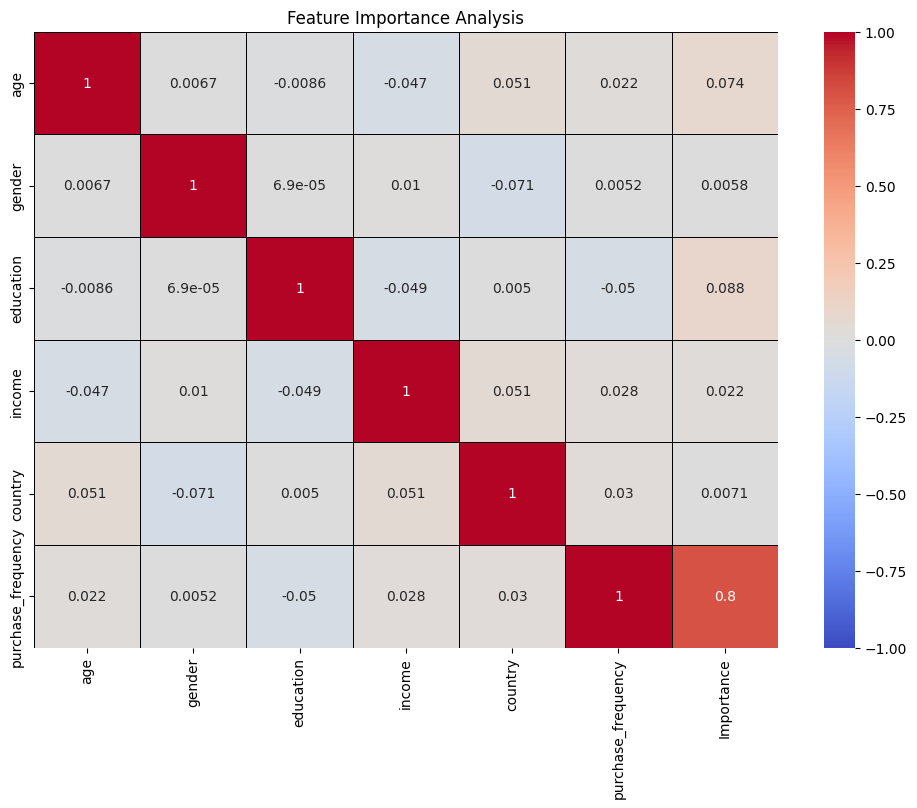

In [71]:
data = data.drop(columns=["name"], errors="ignore")
label_encoder = LabelEncoder()
categorical_columns = ["gender", "education", "country"]
for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])
X = data.drop("spending", axis=1)
y = data["spending"]
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X,y)
feature_importances = rf_regressor.feature_importances_
feature_importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by="Importance", ascending=False)
print("Ranked list of features by importances:")
print(feature_importances_df)
corr_matrix = X.corr()
importances_matrix = corr_matrix.copy()
importances_matrix['Importance'] = pd.Series(feature_importances, index=X.columns)
plt.figure(figsize=(12,8))
sns.heatmap(importances_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='black')
plt.title("Feature Importance Analysis")
plt.show()

Customer Segmentation Analysis with KMeans Clustering

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as py
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [73]:
data = pd.read_csv("customer_data.csv")

/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/si

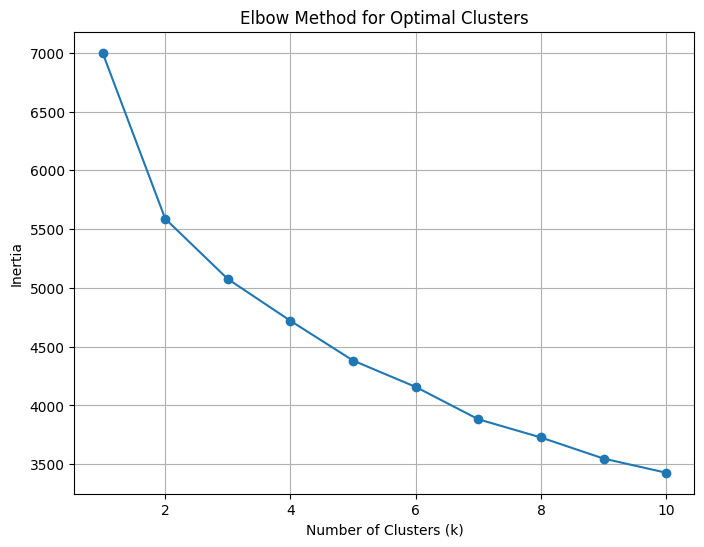

/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/si

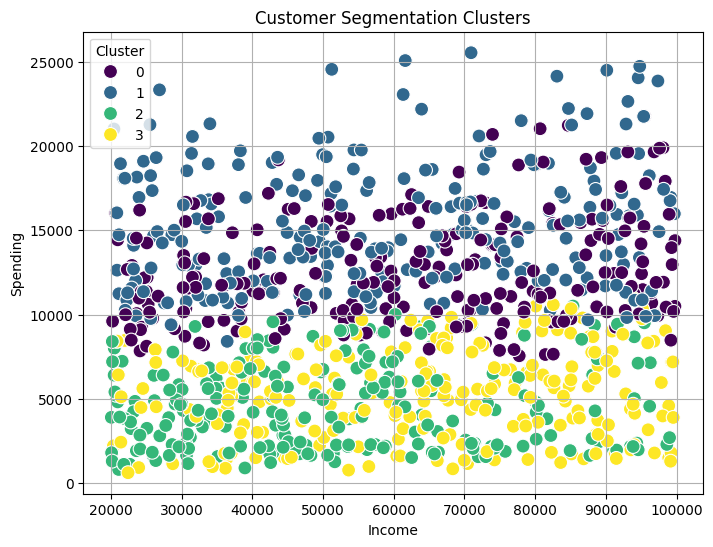

Cluster Centers (Scaled Back):
         age    gender  education        income     country  \
0  46.339844  0.441406   0.410156  62231.804688  119.937500   
1  42.977273  0.469697   2.553030  59022.007576  120.393939   
2  48.110169  0.360169   1.779661  52022.156780  130.381356   
3  29.471311  0.733607   1.073770  63473.241803  103.045082   

   purchase_frequency      spending  
0            0.786328  12639.191973  
1            0.754924  15188.399848  
2            0.241949   4541.620508  
3            0.397131   5311.900369  


In [74]:
data = data.drop(columns=["name"], errors="ignore")
label_encoder = LabelEncoder()
categorical_columns = ["gender", "education", "country"]
for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data)
inertia = []
k_values = range(1,11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(k_values, inertia, marker='o', linestyle='-')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='income', y='spending', hue='Cluster', palette='viridis', s=100)
plt.title("Customer Segmentation Clusters")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()
feature_columns = [col for col in data.columns if col != 'Cluster']
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centers (Scaled Back):")
print(pd.DataFrame(cluster_centers, columns = feature_columns))

Building Customer Spending Prediction Model with Decision Tree Regressor


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

In [76]:

data = pd.read_csv("customer_data.csv")

In [ ]:
label_encoder_gender = LabelEncoder()
label_encoder_country = LabelEncoder()
label_encoder_education = LabelEncoder()
data['gender'] = label_encoder_gender.fit_transform(data['gender'])
data['country'] = label_encoder_country.fit_transform(data['country'])
data['education'] = label_encoder_education.fit_transform(data['education'])
features = ["age","gender","education","income","country", "purchase_frequency"]
target = "spending"
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
print("Enter customer details for spending prediction:")
age = float(input("Age: "))
gender = input("Gender (Male/Female): ")
education = input("Education Level (High School, Bachelor, Master, PhD): ")
income = float(input("Income: "))
country = input("Country: ")
purchase_frequency = float(input("Purchase Frequency: "))
gender_encoded = label_encoder_gender.transform([gender])[0]
country_encoded = label_encoder_country.transform([country])[0]
education_encoded = label_encoder_education.transform([education])[0]
input_data = np.array([[age, gender_encoded, education_encoded, income, country_encoded, purchase_frequency]])
predicted_spending = model.predict(input_data)
print(f"Predicted Customer Spending: $ {predicted_spending[0]:.2f}")

Enter customer details for spending prediction:


Building Customer Churn Prediction Model with SVM


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
data = pd.read_csv("Bank Customer Churn Prediction.csv")

In [3]:

label_encoder_country = LabelEncoder()
data["country"] = label_encoder_country.fit_transform(data["country"])
features = ["credit_score", "country", "age", "tenure", "balance", "estimated_salary"]
target = 'churn'
X = data[features]
y = data[target]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train,y_train)
svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train_resampled, y_train_resampled)
print("Enter customer details for churn prediction:")
credit_score = float(input("Credit Score: "))
country = input("Country: ")
age = float(input("Age: "))
tenure = int(input("Tenure (years with the bank): "))
balance = float(input("Balance: "))
estimated_salary = float(input("Estimated Salary: "))
country_encoded = label_encoder_country.transform([country])[0]
input_data = np.array([[credit_score, country_encoded, age, tenure, balance, estimated_salary]])
input_data_scaled = scaler.transform(input_data)
prediction_proba = svm_model.predict_proba(input_data_scaled)[0]
prediction = svm_model.predict(input_data_scaled)[0]
if prediction == 1:
    print(f"The customer is more likely to churn with a probability of {prediction_proba[1] * 100:.2f}%.")
else:
    print(f"The customer is less likely to churn with a probability of {prediction_proba[0] * 100:.2f}%.")

/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Enter customer details for churn prediction:
The customer is less likely to churn with a probability of 51.59%.


/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Evaluating Model Accuracy & Performance with K-Fold Cross

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, cross_val_score

In [5]:
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%")
def k_fold_cross_validation(X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    cv_scores = cross_val_score(svm_model, X, y, cv=kf, scoring='accuracy')
    print(f"Cross validated accuracy scores: {cv_scores}")
    print(f"Mean Accuracy: {cv_scores.mean() * 100:.2f}%")
    print(f"Standard deviation of accuracy scores: {cv_scores.std():.2f}")
k_fold_cross_validation(x_scaled, y, k=5)

Accuracy Score: 74.30%
Cross validated accuracy scores: [0.7425 0.7245 0.7465 0.7395 0.7385]
Mean Accuracy: 73.83%
Standard deviation of accuracy scores: 0.01


Deploying Machine Learning Model & Creating User Interface with Gradio

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

In [7]:
data = pd.read_csv("customer_data.csv")

In [8]:
label_encoder_gender = LabelEncoder()
label_encoder_country = LabelEncoder()
label_encoder_education = LabelEncoder()
data['gender'] = label_encoder_gender.fit_transform(data['gender'])
data['country'] = label_encoder_country.fit_transform(data['country'])
data['education'] = label_encoder_education.fit_transform(data['education'])
features = ["age","gender","education","income","country", "purchase_frequency"]
target = "spending"
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
print("Enter customer details for spending prediction:")
age = float(input("Age: "))
gender = input("Gender (Male/Female): ")
education = input("Education Level (High School, Bachelor, Master, PhD): ")
income = float(input("Income: "))
country = input("Country: ")
purchase_frequency = float(input("Purchase Frequency: "))
gender_encoded = label_encoder_gender.transform([gender])[0]
country_encoded = label_encoder_country.transform([country])[0]
education_encoded = label_encoder_education.transform([education])[0]
input_data = np.array([[age, gender_encoded, education_encoded, income, country_encoded, purchase_frequency]])
predicted_spending = model.predict(input_data)
print(f"Predicted Customer Spending: $ {predicted_spending[0]:.2f}")

Enter customer details for spending prediction:
Predicted Customer Spending: $ 4484.62


/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [9]:
import gradio as gr

In [10]:
def predict_spending(age,gender,education,income,country,purchase_frequency):
    gender_encoded = label_encoder_gender.transform([gender])[0]
    country_encoded = label_encoder_country.transform([country])[0]
    education_encoded = label_encoder_education.transform([education])[0]
    input_data = np.array([[age, gender_encoded, education_encoded, income, country_encoded, purchase_frequency]])
    predicted_spending = model.predict(input_data)
    return f"Predicted Customer Spending: ${predicted_spending[0]:.2f}"
interaface = gr.Interface(
    fn=predict_spending,
    inputs=[
        gr.Textbox(label="Age"),
        gr.Textbox(label="Gender"),
        gr.Textbox(label="Education Level"),
        gr.Textbox(label="Income"),
        gr.Textbox(label="Country"),
        gr.Textbox(label="Purchase Frequency"),
    ],
    outputs="text"
)
interaface.launch()

Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 4.29.0, however version 4.44.1 is available, please upgrade.
--------


/Users/nikhild/Desktop/Customer Segmentation Analysis And Predict Consumer Behaviour/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
